# Expected Cost of Owning a Home
### A rent-vs-buy / total-cost-of-ownership model with opportunity cost

This notebook computes the **economic cost of owning** over a chosen holding period, framed the way a
trader would: every dollar is discounted at the opportunity cost of capital, leverage on appreciation is
modeled explicitly, and the alternative (rent + invest the freed-up capital) is taxed symmetrically.

**Two outputs:**
1. **NPV cost of ownership** — the literal "expected cost of buying," in today's dollars, plus an
   equivalent annual cost. Opportunity cost is embedded via the discount rate; recovered home equity at
   sale is a negative cost.
2. **Rent-vs-buy terminal wealth** — buyer net worth minus renter net worth at the horizon, with a
   break-even holding period and break-even appreciation rate.

**Modeled explicitly:** amortization (front-loaded interest), property tax / HOA / insurance / maintenance /
PMI with growth, mortgage-interest & SALT deduction caps, standard-vs-itemized threshold, purchase closing
costs, sale/exit costs, primary-residence cap gains exclusion, cap gains drag on the opportunity portfolio,
and leverage (appreciation on full price funded by a fractional down payment).

> Defaults are illustrative (roughly a Cook County condo). Edit the parameter cell and re-run.

In [1]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = lambda x: f"{x:,.2f}"
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Parameters
Everything below is a free parameter. Comments flag the ones people most often get wrong.

In [30]:
@dataclass
class Params:
    # ---- Purchase ----
    house_price: float          = 1_000_000
    down_payment_pct: float     = 0.20      # 20% avoids PMI
    closing_cost_pct: float     = 0.03      # buyer-side closing costs, % of price (~2-4%)

    # ---- Financing ----
    mortgage_rate: float        = 0.0675    # annual nominal APR
    loan_term_years: int        = 30

    # ---- Recurring carry ----
    property_tax_rate: float    = 0.021     # effective, % of home value / yr (Cook County ~2%)
    hoa_monthly: float          = 200.0     # grows with inflation
    insurance_rate: float       = 0.005     # % of home value / yr
    maintenance_rate: float     = 0.010     # % of home value / yr  (~1%; often forgotten, large)
    pmi_rate: float             = 0.006     # % of ORIGINAL loan / yr, while LTV > 80% of orig price

    # ---- Growth / macro ----
    home_appreciation_rate: float = 0.035   # nominal home price growth / yr
    inflation_rate: float         = 0.025   # grows HOA (and rent base if you tie them)
    market_return: float          = 0.070   # opportunity cost of capital = discount rate (pre-tax)
    rent_growth_rate: float       = 0.030   # rent escalation / yr

    # ---- Taxes (deductions) ----
    marginal_income_tax_rate: float      = 0.42     # fed+state marginal, for itemized deductions
    salt_cap: float                      = 10_000   # SALT deduction cap
    salt_headroom: float                 = 0.0      # $ of SALT cap left for PROPERTY tax.
                                                    #   0 => state income tax already exhausts the cap
                                                    #   (realistic for a high earner in IL). Set up to
                                                    #   salt_cap if you have room.
    mortgage_deduction_principal_cap: float = 750_000  # interest deductible only on first $750k of debt
    other_itemized_deductions: float     = 0.0      # charitable, etc. (raises itemized total)
    standard_deduction: float            = 29_200   # MFJ; only deductions ABOVE this have value
    cap_gains_tax_rate: float            = 0.238    # LTCG 20% + 3.8% NIIT (investments & home sale)
    home_sale_exclusion: float           = 500_000  # MFJ primary-residence gain exclusion

    # ---- Sale / exit ----
    selling_cost_pct: float     = 0.06      # realtor + transfer taxes at sale (~5-6%)

    # ---- Horizon ----
    holding_period_years: int   = 30

    # ---- Rent counterfactual (only used in the rent-vs-buy section) ----
    monthly_rent: float         = 5_800.0

p = Params()
p

Params(house_price=1000000, down_payment_pct=0.2, closing_cost_pct=0.03, mortgage_rate=0.0675, loan_term_years=30, property_tax_rate=0.021, hoa_monthly=200.0, insurance_rate=0.005, maintenance_rate=0.01, pmi_rate=0.006, home_appreciation_rate=0.035, inflation_rate=0.025, market_return=0.07, rent_growth_rate=0.03, marginal_income_tax_rate=0.42, salt_cap=10000, salt_headroom=0.0, mortgage_deduction_principal_cap=750000, other_itemized_deductions=0.0, standard_deduction=29200, cap_gains_tax_rate=0.238, home_sale_exclusion=500000, selling_cost_pct=0.06, holding_period_years=30, monthly_rent=5800.0)

## 2. Core simulation engine

Runs a **monthly** loop (so amortization and PMI drop-off are exact), then aggregates to annual for the tax
shield. Key modeling choices:

- **Property tax, insurance, maintenance** scale with the *current* home value (they track the asset).
- **Tax shield** is computed on an itemized-vs-standard basis: only the itemized total *above* the standard
  deduction yields a benefit, at your marginal rate. Mortgage interest is capped to the first \$750k of
  principal; property tax is limited to remaining SALT headroom.
- **Cash outflow includes full P&I** (principal included). That's fine — the principal you pay down is
  recovered as equity at sale, so it nets out correctly in the NPV and in the rent-vs-buy portfolios.
- **Leverage** is automatic: appreciation is applied to the full `house_price`, financed by a fractional
  down payment.

In [31]:
def simulate(p: Params) -> dict:
    r_m   = p.mortgage_rate / 12.0
    n_tot = p.loan_term_years * 12
    loan0 = p.house_price * (1 - p.down_payment_pct)
    down  = p.house_price * p.down_payment_pct
    closing = p.house_price * p.closing_cost_pct

    # Fixed monthly payment (P&I)
    pmt = loan0 * r_m / (1 - (1 + r_m) ** (-n_tot)) if r_m > 0 else loan0 / n_tot

    # Fraction of interest that is deductible (first $750k of principal)
    int_factor = min(1.0, p.mortgage_deduction_principal_cap / loan0) if loan0 > 0 else 0.0

    months = p.holding_period_years * 12
    balance = loan0
    recs = []
    for m in range(1, months + 1):
        year = (m - 1) // 12                      # 0-based year index for HOA inflation
        hv   = p.house_price * (1 + p.home_appreciation_rate) ** (m / 12.0)  # end-of-month value

        interest_m  = balance * r_m
        principal_m = min(pmt - interest_m, balance)
        pay_m       = interest_m + principal_m
        balance    -= principal_m

        prop_tax_m = p.property_tax_rate * hv / 12.0
        ins_m      = p.insurance_rate   * hv / 12.0
        maint_m    = p.maintenance_rate * hv / 12.0
        hoa_m      = p.hoa_monthly * (1 + p.inflation_rate) ** year
        pmi_m      = (p.pmi_rate * loan0 / 12.0) if (balance / p.house_price) > 0.80 else 0.0

        recs.append(dict(month=m, year=year + 1, home_value=hv, balance=balance,
                         interest=interest_m, principal=principal_m, pi=pay_m,
                         prop_tax=prop_tax_m, insurance=ins_m, maintenance=maint_m,
                         hoa=hoa_m, pmi=pmi_m))

    mdf = pd.DataFrame(recs)

    # ---- Annual tax shield (itemized vs standard) ----
    ann = mdf.groupby("year").agg(interest=("interest", "sum"),
                                  prop_tax=("prop_tax", "sum")).reset_index()
    ded_interest = ann["interest"] * int_factor
    ded_prop_tax = np.minimum(ann["prop_tax"], p.salt_headroom)
    itemized     = ded_interest + ded_prop_tax + p.other_itemized_deductions
    ann["tax_benefit"] = np.maximum(0.0, itemized - p.standard_deduction) * p.marginal_income_tax_rate
    benefit_by_year = dict(zip(ann["year"], ann["tax_benefit"]))
    mdf["tax_benefit"] = mdf["year"].map(benefit_by_year) / 12.0

    # Monthly all-in owner cost (cash outflow, net of tax shield)
    mdf["owner_cost"] = (mdf["pi"] + mdf["prop_tax"] + mdf["insurance"] + mdf["maintenance"]
                         + mdf["hoa"] + mdf["pmi"] - mdf["tax_benefit"])
    # Monthly rent path
    mdf["rent"] = p.monthly_rent * (1 + p.rent_growth_rate) ** ((mdf["month"] - 1) // 12)

    # ---- Sale at horizon ----
    T          = p.holding_period_years
    sale_price = p.house_price * (1 + p.home_appreciation_rate) ** T
    rem_bal    = mdf["balance"].iloc[-1]
    sell_costs = sale_price * p.selling_cost_pct
    home_gain  = sale_price - p.house_price
    home_cg_tax = max(0.0, home_gain - p.home_sale_exclusion) * p.cap_gains_tax_rate
    net_proceeds = sale_price - sell_costs - rem_bal - home_cg_tax

    # ---- (A) NPV cost of ownership (discount at market_return) ----
    annual_out = mdf.groupby("year")["owner_cost"].sum()
    npv = down + closing
    for y, out in annual_out.items():
        npv += out / (1 + p.market_return) ** y
    npv -= net_proceeds / (1 + p.market_return) ** T
    crf = (p.market_return * (1 + p.market_return) ** T) / ((1 + p.market_return) ** T - 1) \
          if p.market_return > 0 else 1.0 / T
    eac = npv * crf   # equivalent annual cost

    # ---- (B) Rent-vs-buy terminal wealth (symmetric, cap-gains-taxed) ----
    mret_m = (1 + p.market_return) ** (1 / 12.0) - 1
    port_buy = 0.0;              port_rent = down + closing
    basis_buy = 0.0;            basis_rent = down + closing
    for _, row in mdf.iterrows():
        diff = row["owner_cost"] - row["rent"]        # +: owning costs more this month
        if diff > 0:
            port_rent += diff; basis_rent += diff     # renter invests the surplus
        else:
            port_buy += -diff; basis_buy += -diff     # buyer invests the surplus
        port_buy  *= (1 + mret_m)
        port_rent *= (1 + mret_m)

    port_buy_at  = port_buy  - max(0.0, port_buy  - basis_buy)  * p.cap_gains_tax_rate
    port_rent_at = port_rent - max(0.0, port_rent - basis_rent) * p.cap_gains_tax_rate
    buyer_nw  = port_buy_at + net_proceeds
    renter_nw = port_rent_at
    buy_minus_rent = buyer_nw - renter_nw

    return dict(p=p, monthly=mdf, annual=ann, pmt=pmt, loan0=loan0, down=down, closing=closing,
                sale_price=sale_price, rem_bal=rem_bal, sell_costs=sell_costs,
                home_cg_tax=home_cg_tax, net_proceeds=net_proceeds,
                npv_cost=npv, eac=eac, buyer_nw=buyer_nw, renter_nw=renter_nw,
                buy_minus_rent=buy_minus_rent)

res = simulate(p)
print("engine OK")

engine OK


## 3. Headline results

In [32]:
def summary(res):
    p = res["p"]; m = res["monthly"]
    yr1_cost = m[m["year"] == 1]["owner_cost"].sum() / 12.0
    avg_cost = m["owner_cost"].mean()
    print(f"Home price ................. ${p.house_price:,.0f}   ({p.down_payment_pct:.0%} down = "
          f"${res['down']:,.0f}, +${res['closing']:,.0f} closing)")
    print(f"Loan ...................... ${res['loan0']:,.0f} @ {p.mortgage_rate:.3%}, {p.loan_term_years}y "
          f"-> P&I ${res['pmt']:,.0f}/mo")
    print(f"Holding period ............ {p.holding_period_years} years\n")
    print(f"All-in monthly cost yr 1 .. ${yr1_cost:,.0f}   (avg over hold: ${avg_cost:,.0f})")
    print("-" * 62)
    print("A) ECONOMIC COST OF OWNING (discounted @ market return)")
    print(f"   NPV cost (today's $) ... ${res['npv_cost']:,.0f}")
    print(f"   Equivalent annual cost . ${res['eac']:,.0f} / yr  "
          f"({res['eac']/p.house_price:.2%} of price)")
    print("-" * 62)
    print("   Sale @ horizon:")
    print(f"     Sale price ........... ${res['sale_price']:,.0f}")
    print(f"     - selling costs ...... ${res['sell_costs']:,.0f}")
    print(f"     - loan payoff ........ ${res['rem_bal']:,.0f}")
    print(f"     - home cap gains tax . ${res['home_cg_tax']:,.0f}")
    print(f"     = net proceeds ....... ${res['net_proceeds']:,.0f}")
    print("-" * 62)
    print("B) RENT vs BUY (terminal net worth, cap-gains-taxed)")
    print(f"   Buyer net worth ....... ${res['buyer_nw']:,.0f}")
    print(f"   Renter net worth ...... ${res['renter_nw']:,.0f}   (rent ${p.monthly_rent:,.0f}/mo)")
    verdict = "BUYING wins" if res['buy_minus_rent'] > 0 else "RENTING wins"
    print(f"   Buy - Rent ............ ${res['buy_minus_rent']:,.0f}   -> {verdict}")

summary(res)

Home price ................. $1,000,000   (20% down = $200,000, +$30,000 closing)
Loan ...................... $800,000 @ 6.750%, 30y -> P&I $5,189/mo
Holding period ............ 30 years

All-in monthly cost yr 1 .. $7,704   (avg over hold: $10,441)
--------------------------------------------------------------
A) ECONOMIC COST OF OWNING (discounted @ market return)
   NPV cost (today's $) ... $1,329,847
   Equivalent annual cost . $107,168 / yr  (10.72% of price)
--------------------------------------------------------------
   Sale @ horizon:
     Sale price ........... $2,806,794
     - selling costs ...... $168,408
     - loan payoff ........ $0
     - home cap gains tax . $311,017
     = net proceeds ....... $2,327,369
--------------------------------------------------------------
B) RENT vs BUY (terminal net worth, cap-gains-taxed)
   Buyer net worth ....... $2,327,369
   Renter net worth ...... $2,821,073   (rent $5,800/mo)
   Buy - Rent ............ $-493,704   -> RENTING wins


### Annual cost breakdown

In [13]:
def annual_table(res):
    m = res["monthly"]
    g = m.groupby("year").agg(
        P_and_I=("pi", "sum"), interest=("interest", "sum"), principal=("principal", "sum"),
        prop_tax=("prop_tax", "sum"), hoa=("hoa", "sum"), insurance=("insurance", "sum"),
        maintenance=("maintenance", "sum"), pmi=("pmi", "sum"),
        tax_shield=("tax_benefit", "sum"), net_cost=("owner_cost", "sum"),
        end_balance=("balance", "last"), home_value=("home_value", "last"))
    g["equity"] = g["home_value"] - g["end_balance"]
    return g

annual_table(res)

,P_and_I,interest,principal,prop_tax,hoa,insurance,maintenance,pmi,tax_shield,net_cost,end_balance,home_value,equity
year,,,,,,,,,,,,,
1,"62,265.42","53,739.43","8,525.98","21,396.03","4,800.00","5,094.29","10,188.59",0.00,"8,895.90","94,848.43","791,474.02","1,035,000.00","243,525.98"
2,"62,265.42","53,145.79","9,119.63","22,144.89","4,920.00","5,272.59","10,545.19",0.00,"8,662.15","96,485.94","782,354.38","1,071,225.00","288,870.62"
3,"62,265.42","52,510.81","9,754.61","22,919.97","5,043.00","5,457.13","10,914.27",0.00,"8,412.13","98,187.66","772,599.77","1,108,717.87","336,118.10"
4,"62,265.42","51,831.61","10,433.81","23,722.16","5,169.07","5,648.13","11,296.27",0.00,"8,144.70","99,956.36","762,165.97","1,147,523.00","385,357.03"
5,"62,265.42","51,105.13","11,160.29","24,552.44","5,298.30","5,845.82","11,691.64",0.00,"7,858.64","101,794.97","751,005.68","1,187,686.31","436,680.63"
6,"62,265.42","50,328.06","11,937.36","25,411.77","5,430.76","6,050.42","12,100.85",0.00,"7,552.67","103,706.55","739,068.32","1,229,255.33","490,187.01"
7,"62,265.42","49,496.89","12,768.53","26,301.19","5,566.53","6,262.19","12,524.37",0.00,"7,225.40","105,694.30","726,299.79","1,272,279.26","545,979.48"


## 4. Visuals

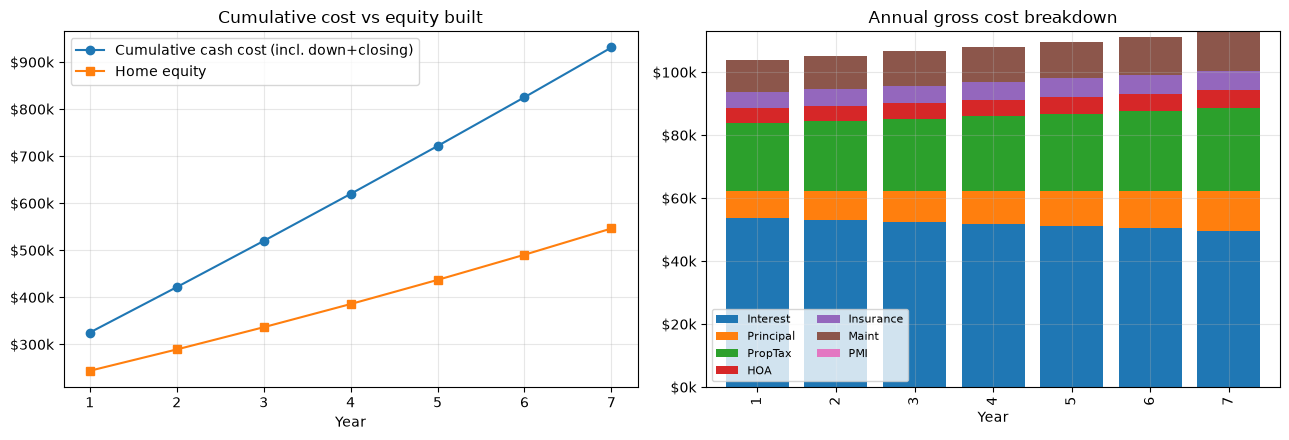

In [14]:
def plot_overview(res):
    m = res["monthly"]; p = res["p"]
    g = m.groupby("year").agg(net_cost=("owner_cost", "sum"),
                              end_balance=("balance", "last"),
                              home_value=("home_value", "last"))
    g["equity"]      = g["home_value"] - g["end_balance"]
    g["cum_net_cost"] = g["net_cost"].cumsum() + res["down"] + res["closing"]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(g.index, g["cum_net_cost"], marker="o", label="Cumulative cash cost (incl. down+closing)")
    ax[0].plot(g.index, g["equity"], marker="s", label="Home equity")
    ax[0].set_title("Cumulative cost vs equity built"); ax[0].set_xlabel("Year"); ax[0].legend()
    ax[0].yaxis.set_major_formatter(lambda x, _: f"${x/1e3:,.0f}k")

    comp = m.groupby("year").agg(Interest=("interest", "sum"), Principal=("principal", "sum"),
                                 PropTax=("prop_tax", "sum"), HOA=("hoa", "sum"),
                                 Insurance=("insurance", "sum"), Maint=("maintenance", "sum"),
                                 PMI=("pmi", "sum"))
    comp.plot(kind="bar", stacked=True, ax=ax[1], width=0.8)
    ax[1].set_title("Annual gross cost breakdown"); ax[1].set_xlabel("Year")
    ax[1].yaxis.set_major_formatter(lambda x, _: f"${x/1e3:,.0f}k")
    ax[1].legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

plot_overview(res)

## 5. Sensitivity & break-evens

The two variables that dominate the buy-vs-rent decision are **appreciation** and **holding period**
(because transaction costs amortize over the hold). The heatmap shows *Buy − Rent* terminal wealth; the
lines below solve for the break-even appreciation rate at your horizon and the break-even holding period at
your assumed appreciation.

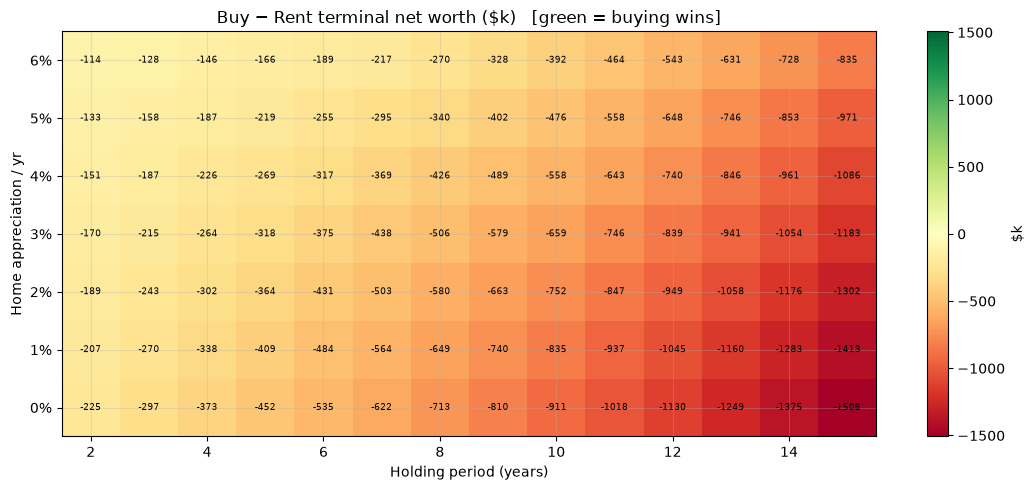

In [15]:
def heatmap_buy_minus_rent(p, appr_grid=None, hold_grid=None):
    from dataclasses import replace
    appr_grid = np.arange(0.00, 0.0651, 0.01) if appr_grid is None else appr_grid
    hold_grid = np.arange(2, 16, 1) if hold_grid is None else hold_grid
    Z = np.zeros((len(appr_grid), len(hold_grid)))
    for i, a in enumerate(appr_grid):
        for j, h in enumerate(hold_grid):
            r = simulate(replace(p, home_appreciation_rate=float(a), holding_period_years=int(h)))
            Z[i, j] = r["buy_minus_rent"] / 1e3

    fig, ax = plt.subplots(figsize=(11, 5))
    lim = np.abs(Z).max()
    im = ax.imshow(Z, origin="lower", aspect="auto", cmap="RdYlGn",
                   vmin=-lim, vmax=lim, extent=[hold_grid[0]-.5, hold_grid[-1]+.5,
                   appr_grid[0]-.005, appr_grid[-1]+.005])
    ax.set_xlabel("Holding period (years)"); ax.set_ylabel("Home appreciation / yr")
    ax.set_title("Buy − Rent terminal net worth ($k)   [green = buying wins]")
    ax.set_yticks(appr_grid); ax.set_yticklabels([f"{a:.0%}" for a in appr_grid])
    for i, a in enumerate(appr_grid):
        for j, h in enumerate(hold_grid):
            ax.text(h, a, f"{Z[i,j]:.0f}", ha="center", va="center", fontsize=6.5)
    plt.colorbar(im, label="$k"); plt.tight_layout(); plt.show()

heatmap_buy_minus_rent(p)

In [16]:
from dataclasses import replace
from scipy.optimize import brentq

def breakeven_appreciation(p):
    f = lambda a: simulate(replace(p, home_appreciation_rate=a))["buy_minus_rent"]
    try:
        return brentq(f, -0.05, 0.20)
    except ValueError:
        return None

def breakeven_hold(p):
    # smallest whole-year hold where buying wins
    for h in range(1, p.loan_term_years + 1):
        if simulate(replace(p, holding_period_years=h))["buy_minus_rent"] > 0:
            return h
    return None

ba = breakeven_appreciation(p); bh = breakeven_hold(p)
print(f"Break-even appreciation @ {p.holding_period_years}y hold : "
      f"{ba:.2%} / yr" if ba is not None else "no break-even in range")
print(f"  (you assumed {p.home_appreciation_rate:.2%})")
print(f"Break-even holding period @ {p.home_appreciation_rate:.2%} appr : "
      f"{bh} years" if bh else "buying never wins in loan term")

Break-even appreciation @ 7y hold : 9.42% / yr
  (you assumed 3.50%)
buying never wins in loan term


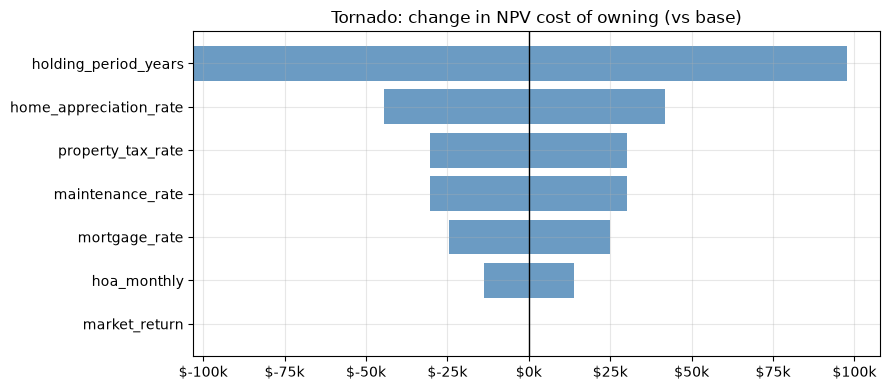

,param,low_shock,high_shock,range
2,market_return,-261.72,-126.77,134.95
5,hoa_monthly,"-13,853.13","13,853.13","27,706.27"
0,mortgage_rate,"-24,367.77","24,792.45","49,160.21"
4,maintenance_rate,"-30,229.31","30,229.31","60,458.61"
3,property_tax_rate,"-30,229.31","30,229.31","60,458.61"
1,home_appreciation_rate,"41,883.66","-44,554.27","86,437.93"
6,holding_period_years,"-102,994.28","97,810.71","200,804.99"


In [17]:
# One-factor tornado: how each assumption moves the NPV cost of owning (+/- shock)
from dataclasses import replace
def tornado(p):
    base = simulate(p)["npv_cost"]
    shocks = {
        "mortgage_rate":          ("mortgage_rate",          p.mortgage_rate,          0.01),
        "home_appreciation_rate": ("home_appreciation_rate", p.home_appreciation_rate, 0.01),
        "market_return":          ("market_return",          p.market_return,          0.01),
        "property_tax_rate":      ("property_tax_rate",      p.property_tax_rate,      0.005),
        "maintenance_rate":       ("maintenance_rate",       p.maintenance_rate,       0.005),
        "hoa_monthly":            ("hoa_monthly",            p.hoa_monthly,            200),
        "holding_period_years":   ("holding_period_years",   p.holding_period_years,   2),
    }
    rows = []
    for name, (attr, val, d) in shocks.items():
        lo = simulate(replace(p, **{attr: type(val)(val - d)}))["npv_cost"]
        hi = simulate(replace(p, **{attr: type(val)(val + d)}))["npv_cost"]
        rows.append((name, lo - base, hi - base, abs(hi - lo)))
    t = pd.DataFrame(rows, columns=["param", "low_shock", "high_shock", "range"]).sort_values("range")

    fig, ax = plt.subplots(figsize=(9, 4))
    y = np.arange(len(t))
    ax.barh(y, t["high_shock"] - t["low_shock"], left=t["low_shock"], color="steelblue", alpha=.8)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(t["param"])
    ax.set_title("Tornado: change in NPV cost of owning (vs base)")
    ax.xaxis.set_major_formatter(lambda x, _: f"${x/1e3:,.0f}k")
    plt.tight_layout(); plt.show()
    return t

tornado(p)

## 6. Notes, assumptions & extensions

**What's modeled**
- Exact monthly amortization (front-loaded interest); PMI auto-terminates at 80% LTV of original price.
- Property tax / insurance / maintenance scale with current home value; HOA grows with inflation.
- Tax shield uses itemized-vs-standard: only itemized total above the standard deduction has value;
  mortgage interest capped to first \$750k of debt; property tax limited to `salt_headroom`.
- Symmetric rent-vs-buy: both scenarios start with equal wealth; the cheaper party each month invests the
  surplus at `market_return`; both portfolios pay cap gains tax at liquidation; home sale uses the
  \$500k MFJ exclusion.
- Leverage is explicit — appreciation on the full price, funded by a fractional down payment.

**Simplifications you may want to refine**
- Investment return is applied as price appreciation only; dividend/annual tax drag is deferred to
  liquidation (mild optimism for the renter). Swap in an after-tax annual return if you prefer.
- Property tax assumed to track market value 1:1 (Cook County assessment lag/caps ignored).
- No mortgage points, recast, or refinancing; fixed rate only.
- `salt_headroom` defaults to 0 (state income tax assumed to exhaust the SALT cap). Raise it if you have room.
- Rent assumed frictionless (no moving costs, no landlord risk); owning assumed fully occupied (primary residence).

**Natural extensions**
- Monte Carlo over `home_appreciation_rate` and `market_return` (correlated) → distribution of Buy − Rent,
  not just a point estimate. The `simulate()` function is already vectorizable across draws.
- Add a 15y vs 30y term toggle and compare EAC.
- Add state-specific transfer taxes to `selling_cost_pct` explicitly.